# P1 · Data Generation & Proxy Calibration

**Week 1 of the Two-Sided Pricing & Elasticity Decision Engine.** This notebook narrates
`data/generate.py`: calibrate price elasticity and seasonality on the UCI Online Retail II
proxy, then generate the marketplace `transactions`, `partners`, and `capacity` tables on
top of that calibration (per `docs/02_data_and_method.md`). Everything here is
**simulated/calibrated**, not real marketplace data.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from src import capacity, partners, proxy, transactions
from src.config import JOB_TYPES, REFERENCE_WAGE

pd.set_option("display.max_columns", None)

## 1. Calibrate on the UCI Online Retail II proxy

In [2]:
calibration = proxy.calibrate()
elasticity_dist = calibration["elasticity"]
seasonality = calibration["seasonality"]

print(f"Elasticity distribution: mean={elasticity_dist['mean']:.3f}, "
      f"std={elasticity_dist['std']:.3f}, n_products={elasticity_dist['n']}")
seasonality

Elasticity distribution: mean=-2.116, std=2.161, n_products=277


dow
0    1.261169
1    1.332063
2    1.259505
3    1.457126
4    1.041066
5    0.003138
6    0.645934
Name: Quantity, dtype: float64

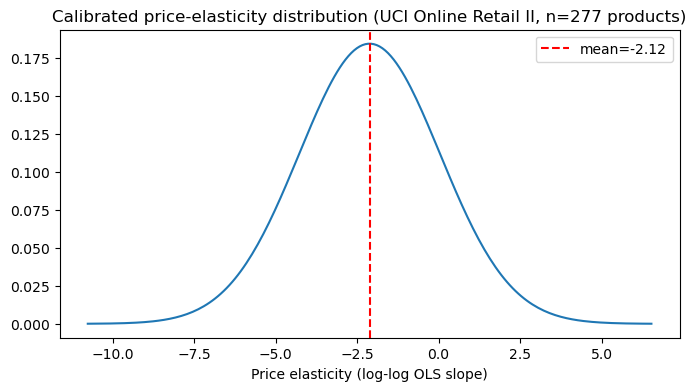

In [3]:
x = np.linspace(elasticity_dist["mean"] - 4 * elasticity_dist["std"],
                 elasticity_dist["mean"] + 4 * elasticity_dist["std"], 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, norm.pdf(x, elasticity_dist["mean"], elasticity_dist["std"]))
ax.axvline(elasticity_dist["mean"], color="red", linestyle="--", label=f"mean={elasticity_dist['mean']:.2f}")
ax.set_title(f"Calibrated price-elasticity distribution (UCI Online Retail II, n={elasticity_dist['n']} products)")
ax.set_xlabel("Price elasticity (log-log OLS slope)")
ax.legend()
plt.show()

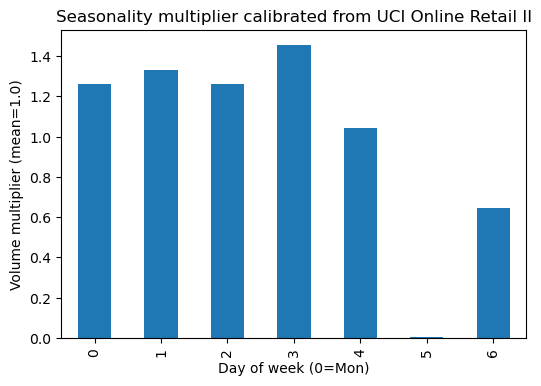

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
seasonality.plot(kind="bar", ax=ax)
ax.set_xlabel("Day of week (0=Mon)")
ax.set_ylabel("Volume multiplier (mean=1.0)")
ax.set_title("Seasonality multiplier calibrated from UCI Online Retail II")
plt.show()

## 2. Generate partners, capacity, and transactions

In [5]:
partners_df = partners.simulate_partners()
capacity_df = capacity.simulate_capacity(partners_df)
transactions_df = transactions.simulate_transactions(elasticity_dist, seasonality)

print(f"partners: {len(partners_df):,} rows | capacity: {len(capacity_df):,} rows | "
      f"transactions: {len(transactions_df):,} rows")
transactions_df.head()

partners: 400 rows | capacity: 520 rows | transactions: 108,957 rows


,date,city,job_type,list_price,discount,booked,gmv,units
0,2024-01-01,Delhi,cleaning,502.74,0.000,1,502.74,1
1,2024-01-01,Delhi,cleaning,517.11,0.000,0,0.00,1
2,2024-01-01,Delhi,cleaning,488.57,0.074,0,0.00,1
3,2024-01-01,Delhi,cleaning,518.04,0.235,1,396.18,1
4,2024-01-01,Delhi,cleaning,510.45,0.055,1,482.27,1


In [6]:
partners_df.head()

,partner_id,city,skill,tenure_months,jobs_done,earnings_per_job,churn_probability,churn_flag,active_flag
0,P00001,Delhi,cleaning,4,31,320.94,0.0378,0,1
1,P00002,Delhi,cleaning,28,237,304.91,0.0446,0,1
2,P00003,Delhi,cleaning,7,59,304.46,0.0448,0,1
3,P00004,Delhi,cleaning,34,275,329.39,0.0356,0,1
4,P00005,Delhi,cleaning,6,45,333.63,0.0347,0,1


In [7]:
capacity_df.head()

,city,job_type,week,available_partner_hours
0,Delhi,cleaning,2024-01-01,1166.5
1,Delhi,cleaning,2024-01-08,1250.4
2,Delhi,cleaning,2024-01-15,1011.9
3,Delhi,cleaning,2024-01-22,994.2
4,Delhi,cleaning,2024-01-29,1161.1


## 3. Diagnostic plots

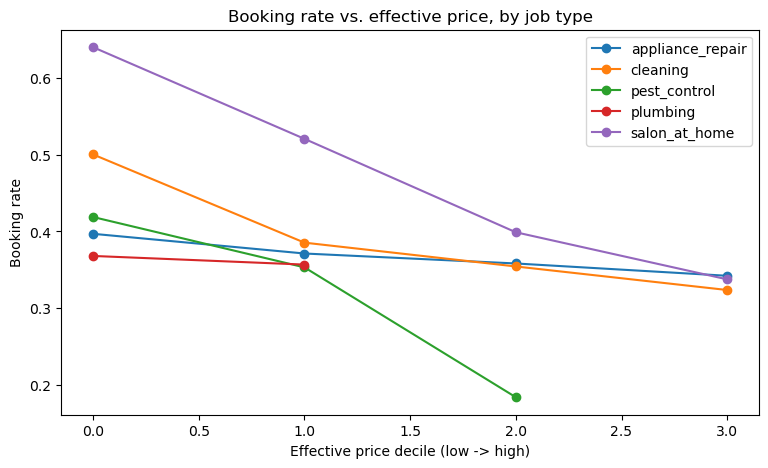

In [8]:
df = transactions_df.copy()
df["effective_price"] = df["list_price"] * (1 - df["discount"])
df["price_bin"] = pd.qcut(df["effective_price"], 10, duplicates="drop")

fig, ax = plt.subplots(figsize=(9, 5))
for job_type, g in df.groupby("job_type"):
    binned = g.groupby("price_bin", observed=True)["booked"].mean()
    ax.plot(range(len(binned)), binned.values, marker="o", label=job_type)
ax.set_xlabel("Effective price decile (low -> high)")
ax.set_ylabel("Booking rate")
ax.set_title("Booking rate vs. effective price, by job type")
ax.legend()
plt.show()

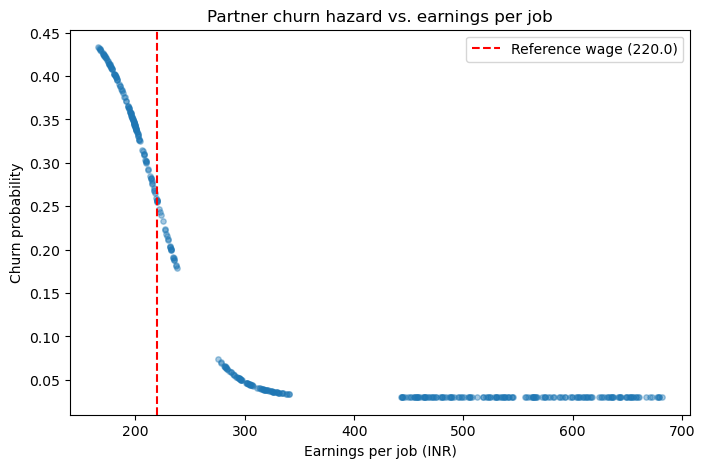

In [9]:
sorted_p = partners_df.sort_values("earnings_per_job")
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sorted_p["earnings_per_job"], sorted_p["churn_probability"], alpha=0.4, s=15)
ax.axvline(REFERENCE_WAGE, color="red", linestyle="--", label=f"Reference wage ({REFERENCE_WAGE})")
ax.set_xlabel("Earnings per job (INR)")
ax.set_ylabel("Churn probability")
ax.set_title("Partner churn hazard vs. earnings per job")
ax.legend()
plt.show()

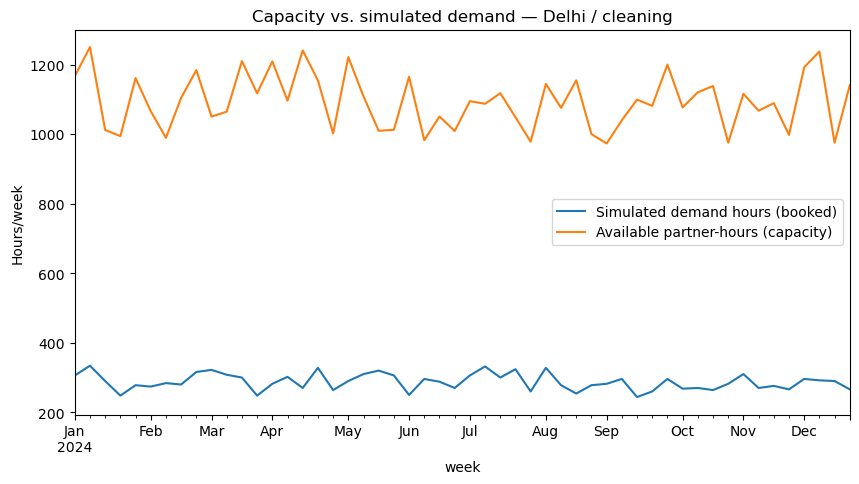

In [10]:
city, job_type = "Delhi", "cleaning"
hours_per_job = JOB_TYPES[job_type]["hours_per_job"]

tx = transactions_df[(transactions_df["city"] == city) & (transactions_df["job_type"] == job_type)].copy()
tx["week"] = pd.to_datetime(tx["date"]).dt.to_period("W").dt.start_time
weekly_demand_hours = tx.groupby("week")["booked"].sum() * hours_per_job

cap = capacity_df[(capacity_df["city"] == city) & (capacity_df["job_type"] == job_type)].set_index("week")["available_partner_hours"]

fig, ax = plt.subplots(figsize=(10, 5))
weekly_demand_hours.plot(ax=ax, label="Simulated demand hours (booked)")
cap.plot(ax=ax, label="Available partner-hours (capacity)")
ax.set_title(f"Capacity vs. simulated demand — {city} / {job_type}")
ax.set_ylabel("Hours/week")
ax.legend()
plt.show()

## So what

The proxy-calibrated elasticities come out negative for every segment, as expected, and the
day-of-week seasonality gives the transaction volume a realistic weekly rhythm instead of a
flat draw. More importantly: the partner churn hazard visibly **kinks upward** once
`earnings_per_job` drops below the ₹220 reference wage — this is not a smooth curve, it's a
threshold effect, and segments priced near or below it (e.g. `plumbing`, `appliance_repair`
at deeper discounts) are exactly where a single-sided, customer-only pricing view would miss
the retention and serviceability damage.

**Next (Week 2):** fit the demand elasticity properly per segment (statsmodels, with
confidence intervals) and an ML price-response model, then build the price → earnings →
churn model on top of this data. **Week 3** adds the serviceability constraint and the
constrained optimizer that this data was generated to feed.